# NB-0 — Foundations: Python, Data & Statistics

**Course:** MAM5017S — An Introduction to Machine Learning for Neuroscientists

**When:** pre-course · self-paced · ungraded

**Why this matters.** Everything we do this term rests on two things: writing a bit of Python, and reasoning about noisy measurements. This notebook gets both back up to speed before the first lecture, and it teaches them together, because in practice you never do one without the other.

Nothing here is graded and nothing is a test, so use whatever help you like, AI tools included. This is reaching you a few days before the first lecture rather than at the start of the vacation, so please do not try to cram it. Get as far as you sensibly can before Wednesday and pick up the rest in the week that follows: NB-1, the first lecture notebook, only arrives after lecture 1, so there is genuine room to keep going. A few good hours spent here is repaid several times over, and the best thing you can do with it is bring your questions to lectures 1 and 2.

### How to work through it

There is a fair amount of reading here as well as typing, and that is deliberate: the explanations matter as much as the code. You do not need to finish it in one sitting, or even before the first lecture.

Sections 1 to 3 are a Python and plotting refresher, so skim them if you already write Python comfortably. Sections 4 to 8 are the probability and statistics that lectures **L2**, **L5** and **L6** will assume, and they are the part worth slowing down for. If you have never taken a statistics course, that half is written for you: it is a first look rather than a course in its own right, so that when these ideas arrive in a lecture you are re-meeting them rather than meeting them cold. Section 9 is a small project that uses both halves.

If you are short of time before Wednesday, prioritise sections 1, 2, 3 and 6, which are the Python, NumPy, plotting and pandas, because lecture 1 goes straight into fitting a model in code. The statistics in sections 4, 5, 7 and 8 matter most for lecture 2, so they can comfortably wait until the week after.

Most sections introduce an idea, show it working, and then hand you a **Task** to write yourself, marked `# YOUR CODE HERE`. Underneath each sits a **Check** that prints ✅ or ❌ with a hint; a ❌ only means "not done yet", and the checks never raise an error, so *Run all* finishes cleanly even on a blank notebook. Each task has a **Solution** folded away beneath it, and cells marked 🔧 start collapsed because they hold plumbing you can ignore.

### What you'll take away

By the end you should be able to:

- write basic Python: variables, control flow, functions and f-strings,
- create and manipulate NumPy arrays, including indexing, masking and broadcasting,
- draw labelled matplotlib figures: scatter, histogram and boxplot,
- say what a probability and a distribution are, in your own words,
- recognise the Bernoulli, binomial and normal distributions when they come up,
- build a pandas `DataFrame`, filter it and summarise it with `groupby`,
- compute descriptive statistics and say which of them survive an outlier,
- explain why the mean of a sample is itself a noisy quantity, and what the Central Limit Theorem claims.

### Running the cells

Run a cell by clicking into it and pressing **Shift+Enter**. All the cells share one memory, so order matters: run them out of sequence and you can end up using a variable that no longer holds what you think it does. If something stops making sense, run everything again from the top. That also keeps the **random seed** set in the next section doing its job, which is what makes your "random" numbers match the ones quoted in the text.

### The shape of the whole course

Almost everything we do in MAM5017S is the same three-step loop, applied to progressively richer models. We **propose a model**, which is a guess at how the data was produced; we **fit it** to the data we actually have; and then we **check it**, asking whether it describes the data and whether it *generalises* to data it has never seen.

We need that loop because real measurements are **signal plus noise**: the firing rate we care about, plus jitter from the biology and from the recording equipment. Statistics and machine learning are the principled ways of pulling the signal back out, which is why this notebook covers the reasoning alongside the code. The project in section 9 is that loop in miniature.

## Setup

Two conventions run through every notebook this term. The first is `rng`, a seeded random-number generator, which is what makes anything "random" come out the same for you as it does for me. The second is a small fixed palette of three colours, so that a figure means the same thing in week one as it does in week eleven: blue for condition A or training data, orange for condition B or held-out data, and teal for everything neuroscience-flavoured.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Fixed course colour code (re-used in every notebook)
C_TRAIN = "#185FA5"  # condition A / training data
C_TEST = "#D85A30"   # condition B / held-out data
C_NEURO = "#0E8C76"  # neuroscience data points

print("NumPy", np.__version__, "· pandas", pd.__version__)

NumPy 2.0.2 · pandas 2.2.2


The next cell is the first collapsed 🔧 helper. It defines the ✅/❌ machinery and one small plotting convenience. Run it and move on.

In [2]:
#@title 🔧 Course helpers (run me, no need to read)
import matplotlib as mpl
from ipywidgets import interact, IntSlider, FloatSlider

_checks = []


def check(label, ok, hint=""):
    """Record and print a soft pass/fail.

    `ok` may be a plain boolean or a zero-argument function. Passing a function
    lets the Check cells hold the plain expression a student would write, without
    guarding against every way an unfinished Task could blow up: anything that
    raises in here is simply reported as "not done yet".
    """
    if callable(ok):
        try:
            ok = ok()
        except Exception:
            ok = False
    ok = bool(ok)
    _checks.append((label, ok))
    line = f"{'✅' if ok else '❌'}  {label}"
    if not ok and hint:
        line += f"\n     ↳ {hint}"
    print(line)


def score():
    """Summarise all checks run so far."""
    total = len(_checks)
    passed = sum(ok for _, ok in _checks)
    print(f"\n{passed}/{total} checks passing.")
    if total and passed == total:
        print("All green. You're warmed up for MAM5017S, see you in class.")
    else:
        missing = [lbl for lbl, ok in _checks if not ok]
        print("Not done yet:", ", ".join(missing))
        print("Fill the Task cell above each ❌ and re-run. Open the Solution if you are stuck.")


def boxplot(ax, data, labels, **kw):
    """ax.boxplot, with whichever label keyword the installed matplotlib wants.

    The keyword was renamed `labels` -> `tick_labels` in matplotlib 3.9.
    """
    major_minor = tuple(int(x) for x in mpl.__version__.split(".")[:2])
    key = "tick_labels" if major_minor >= (3, 9) else "labels"
    return ax.boxplot(data, **{key: labels}, **kw)


print("Helpers ready: check(), score(), boxplot().")

Helpers ready: check(), score(), boxplot().


## 1. Python basics

Variables, types, f-strings and control flow. You will reach for these in every notebook this term, so it is worth being fluent rather than merely able.

### Variables and types

Python works out the type for you, so you never declare one. These four cover most of what we need: whole numbers, decimals, text and true/false values.

In [3]:
n_neurons = 120          # int
firing_rate = 8.5        # float, in Hz
region = "hippocampus"   # str
is_active = True         # bool

### f-strings

Putting an `f` in front of a string lets you drop a variable, or any expression, straight into it inside curly braces. This is the tidiest way to print a result with its units attached, and you will see it constantly from here on.

In [4]:
print(f"Recorded {n_neurons} neurons in the {region} at ~{firing_rate} Hz.")
print(f"Active? {is_active}. Twice the rate would be {2 * firing_rate} Hz.")

Recorded 120 neurons in the hippocampus at ~8.5 Hz.
Active? True. Twice the rate would be 17.0 Hz.


### Lists, dictionaries and loops

A **list** holds things in order, and a **dictionary** maps a key to a value, in the way a lookup table would. A `for` loop walks through either of them one item at a time.

In [5]:
conditions = ["rest", "task", "rest", "task", "task"]
mean_rt = {"rest": 540.0, "task": 410.0}   # mean reaction time (ms) per condition

for cond in conditions:
    print(f"Condition '{cond}' → mean RT {mean_rt[cond]} ms")

Condition 'rest' → mean RT 540.0 ms
Condition 'task' → mean RT 410.0 ms
Condition 'rest' → mean RT 540.0 ms
Condition 'task' → mean RT 410.0 ms
Condition 'task' → mean RT 410.0 ms


### Task 1 — write a function with `if` / `elif` / `else`

Complete `classify_rt` so that it labels a reaction time in milliseconds: `"fast"` if it is under 350, `"slow"` if it is over 600, and `"typical"` for anything in between.

In [6]:
def classify_rt(rt_ms):
    """Label a reaction time as 'fast', 'typical' or 'slow'."""
    if rt_ms < 350:
        return "fast"
    elif rt_ms <= 600:
        return "typical"
    else:
        return "slow"


In [7]:
# ✅ CHECK 1
check("classify_rt(300) == 'fast'", lambda: classify_rt(300) == "fast",
      hint="return 'fast' when rt_ms < 350")
check("classify_rt(450) == 'typical'", lambda: classify_rt(450) == "typical",
      hint="the middle band is 350 to 600 inclusive")
check("classify_rt(720) == 'slow'", lambda: classify_rt(720) == "slow",
      hint="return 'slow' when rt_ms > 600")

✅  classify_rt(300) == 'fast'
✅  classify_rt(450) == 'typical'
✅  classify_rt(720) == 'slow'


<details><summary>💡 Reveal solution (Task 1)</summary>

```python
def classify_rt(rt_ms):
    if rt_ms < 350:
        return "fast"
    elif rt_ms <= 600:
        return "typical"
    else:
        return "slow"
```
</details>

## 2. NumPy

NumPy gives us the **array**: a grid of numbers that all share one type, which Python can do arithmetic on in one go rather than one element at a time. That last part is what people mean by **vectorised** code. Writing `a * 2` multiplies every element at once, in compiled code underneath, and it is both shorter to read and far faster than the equivalent loop. Almost all numerical work in Python sits on top of NumPy, and every model we fit this term is NumPy somewhere underneath.

### Making arrays

Four ways to get one: from a list you already have, filled with zeros, as a range with a fixed step, or as a set number of evenly spaced points between two ends.

In [8]:
a = np.array([1, 2, 3, 4, 5])
zeros = np.zeros(4)
ramp = np.arange(0, 10, 2)        # 0, 2, 4, 6, 8
grid = np.linspace(0, 1, 5)       # 5 points evenly spaced from 0 to 1

print("a        :", a)
print("zeros    :", zeros)
print("ramp     :", ramp)
print("linspace :", np.round(grid, 2))

a        : [1 2 3 4 5]
zeros    : [0. 0. 0. 0.]
ramp     : [0 2 4 6 8]
linspace : [0.   0.25 0.5  0.75 1.  ]


### Indexing, slicing and masks

Positions count from 0 rather than 1, so `a[0]` is the first element, and a negative position counts back from the end. A slice `a[1:4]` runs from the first index up to *but not including* the second, which trips up almost everyone at least once.

The last line below is the one to pay attention to. You can index with a *condition* rather than a position, and `a[a > 2]` keeps only the elements where the condition holds. This is called **boolean masking**. It is how we filter data for the rest of the term, and in section 4 it turns out to be the thing that lets us simulate a probability directly.

In [9]:
print("first element :", a[0])
print("last element  :", a[-1])
print("middle three  :", a[1:4])
print("every other   :", a[::2])
print("values > 2    :", a[a > 2])   # boolean ("mask") indexing

first element : 1
last element  : 5
middle three  : [2 3 4]
every other   : [1 3 5]
values > 2    : [3 4 5]


### Broadcasting

When you combine two arrays of different shapes, NumPy **stretches** the smaller one so that element-wise arithmetic still makes sense, without you writing a loop and without it ever actually copying the data in memory. Adding a row of three per-column offsets to a 2×3 matrix applies that same row to both rows of the matrix:

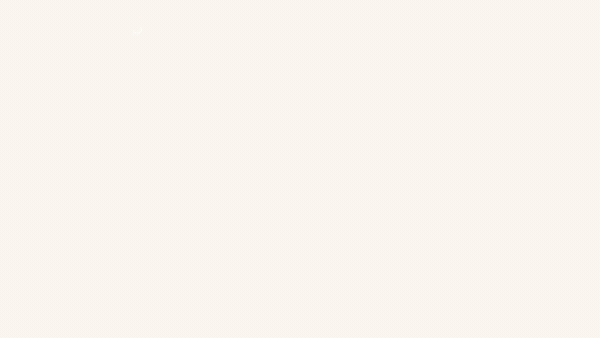

In [10]:
matrix = np.array([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])
col_offset = np.array([10.0, 20.0, 30.0])   # shape (3,) broadcasts across the 2 rows

print("matrix + col_offset =\n", matrix + col_offset)

matrix + col_offset =
 [[11. 22. 33.]
 [14. 25. 36.]]


### Task 2 — centre each neuron using broadcasting

`firing` below is a 3 neurons × 4 trials matrix, one neuron per row. Compute `centred`: each neuron's firing rate with *its own* row mean subtracted, so that every neuron is expressed relative to its own baseline rather than to the population. Subtracting a baseline like this is one of the most common things you will ever do to neural data.

Two bits of NumPy vocabulary you need. `axis=1` means "collapse along the trials, giving me one number per row"; `axis=0` would go the other way and give one number per column. `keepdims=True` asks for the result as a `(3, 1)` column rather than a flat list of 3, and that shape is what lets it broadcast back across the trials. Do it without writing a loop.

In [11]:
firing = np.array([[ 5.0,  7.0,  6.0,  6.0],    # neuron 0
                   [12.0, 10.0, 14.0, 12.0],    # neuron 1
                   [ 2.0,  3.0,  2.0,  1.0]])   # neuron 2

centred = firing - firing.mean(axis=1, keepdims=True)


In [12]:
# ✅ CHECK 2
check("centred has the same shape as firing",
      lambda: np.shape(centred) == (3, 4),
      hint="the result should still be 3 rows by 4 trials")
check("each neuron's centred row sums to ≈ 0",
      lambda: np.allclose(np.sum(centred, axis=1), 0.0),
      hint="subtract firing.mean(axis=1, keepdims=True)")

✅  centred has the same shape as firing
✅  each neuron's centred row sums to ≈ 0


<details><summary>💡 Reveal solution (Task 2)</summary>

```python
centred = firing - firing.mean(axis=1, keepdims=True)
```
</details>

## 3. Seeing your data

Plots let you *see* your data before you reason about it, which catches the sort of problem no summary number will ever tell you about. One rule holds all term: **always label your axes**. A reader who cannot tell what has been plotted has no way to judge whether you are right.

Every figure starts with `fig, ax = plt.subplots()`. That hands you a *figure*, which is the canvas, and an *axes*, which is the actual plotting area you draw into. Almost everything else is a method you call on `ax`.

### A scatter plot

A scatter plot puts one dot per observation and is how you look for a relationship between two measured quantities. Here we have eight trials, and we draw one condition at a time so that each gets its own colour and its own legend entry.

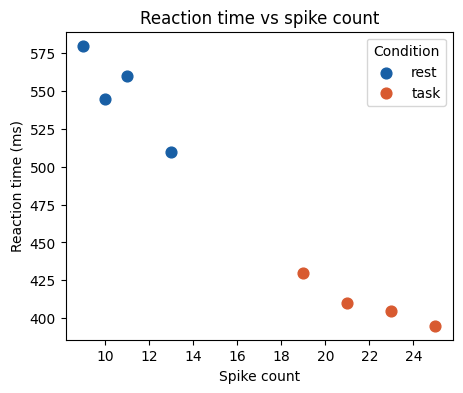

In [13]:
spike_count = np.array([11, 9, 13, 10, 21, 25, 19, 23])
reaction_ms = np.array([560.0, 580.0, 510.0, 545.0, 410.0, 395.0, 430.0, 405.0])
is_task = np.array([False, False, False, False, True, True, True, True])

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(spike_count[~is_task], reaction_ms[~is_task], label="rest", color=C_TRAIN, s=60)
ax.scatter(spike_count[is_task], reaction_ms[is_task], label="task", color=C_TEST, s=60)

ax.set_xlabel("Spike count")
ax.set_ylabel("Reaction time (ms)")
ax.set_title("Reaction time vs spike count")
ax.legend(title="Condition")
plt.show()

Notice that we used a mask twice there. `is_task` is an array of True/False, and `~is_task` flips it, so the two calls draw the two conditions without a loop or an `if` anywhere.

### Task 3 — make a labelled histogram

A **histogram** sorts values into bins and draws a bar for how many landed in each. It is how you look at the shape of a single batch of numbers rather than a relationship between two, and from section 5 onwards it is the picture we use for almost everything.

`rts` below is a set of simulated reaction times. (`rng.normal` draws from a *normal* distribution; for now read that as "realistic-looking measurement noise scattered around 480 ms", and section 5 says what it properly means.) Draw a histogram of them into the axes `ax`, then label the x-axis `"Reaction time (ms)"` and the y-axis `"Count"`. We cannot grade how a plot looks, so the check only confirms that you drew bars and labelled both axes.

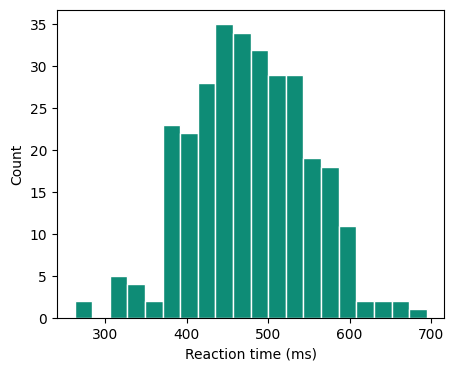

In [14]:
rts = rng.normal(loc=480, scale=70, size=300)

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(rts, bins=20, color=C_NEURO, edgecolor='white')
ax.set_xlabel("Reaction time (ms)")
ax.set_ylabel("Count")

plt.show()

In [15]:
# ✅ CHECK 3
check("you drew some histogram bars", lambda: len(ax.patches) > 0,
      hint="ax.hist(rts, bins=20, color=C_NEURO, edgecolor='white')")
check("x-axis is labelled", lambda: ax.get_xlabel().strip() != "",
      hint="ax.set_xlabel('Reaction time (ms)')")
check("y-axis is labelled", lambda: ax.get_ylabel().strip() != "",
      hint="ax.set_ylabel('Count')")

✅  you drew some histogram bars
✅  x-axis is labelled
✅  y-axis is labelled


<details><summary>💡 Reveal solution (Task 3)</summary>

```python
ax.hist(rts, bins=20, color=C_NEURO, edgecolor="white")
ax.set_xlabel("Reaction time (ms)")
ax.set_ylabel("Count")
```
</details>

## 4. Probability, by simulation

From here on the notebook shifts from *how do I write this* to *how do I reason about this*. This is the material lectures L2, L5 and L6 assume, and it is where to slow down if your statistics is rusty or absent.

A **probability** is just a number between 0 and 1 saying how often something happens in the long run. Picture a neuron in a short time bin: either it fires, which we write as 1, or it does not, which we write as 0. If it fires with probability `p`, then over enough bins the fraction that came out as 1 should settle near `p`.

That last sentence is worth taking literally, because it is the idea the rest of the notebook is built on. Rather than trusting a formula, we can *simulate* the thing many times and look at what actually comes out. Almost everything below is that same move, and the tool that makes it possible is the boolean mask from section 2.

In [16]:
p = 0.3
fired = rng.random(10_000) < p    # a mask: True in every bin where the neuron "fired"

print(f"target p = {p};  observed firing rate = {fired.mean():.3f}")

target p = 0.3;  observed firing rate = 0.301


Read that middle line carefully, because it is doing more than it looks. `rng.random(10_000)` gives ten thousand numbers spread evenly between 0 and 1, and asking which of them are below `0.3` gives a mask that is True about 30% of the time. Taking the mean of a True/False array counts the Trues, since Python treats True as 1. So a probability, a mask and an average turn out to be the same computation seen from three angles.

### Task 4 — independence

Two events are **independent** when knowing one happened tells you nothing about the other. For independent events the probability that *both* happen is the product of their separate probabilities.

So if two neurons each fire independently with probability `p = 0.3`, set `p_both` to the chance that they both fire in the same bin. We check it against a simulation, so either the exact formula or a simulated estimate will pass.

In [17]:
p = 0.3

p_both = p * p

In [18]:
# ✅ CHECK 4
_sim = ((rng.random(50_000) < p) & (rng.random(50_000) < p)).mean()

check("P(both fire) ≈ p × p", lambda: abs(p_both - 0.09) < 0.01,
      hint="p_both = p * p")
check("… and it matches a simulation", lambda: abs(p_both - _sim) < 0.02,
      hint=f"the simulated estimate is ≈ {_sim:.3f}")

✅  P(both fire) ≈ p × p
✅  … and it matches a simulation


<details><summary>💡 Reveal solution (Task 4)</summary>

```python
p_both = p * p   # = 0.09
```
</details>

## 5. Distributions

Before naming any, it is worth being plain about what the word means, because it gets used as though everyone already knows. A **distribution** describes which values a quantity takes and how often it takes them. That really is all it is, and you have already drawn one: the histogram in section 3 was a picture of a distribution, with the values along the bottom and how often each occurred as the height.

Three named distributions come up often enough in neuroscience to be worth recognising on sight. You do not need to memorise any formulas and we will not ask you to derive anything. Being able to recognise the shape, and having a rough sense of when each turns up, is plenty for now.

A **Bernoulli** is the simplest thing that can happen: one single yes-or-no event, like the neuron firing in one short bin that we simulated a moment ago. A **binomial** is what you get from counting up many independent Bernoulli trials, so it describes the number of spikes in a window of `n` bins. A **normal** distribution, also called a Gaussian, is the familiar bell shape; membrane-voltage noise and measurement error usually look like this, and it is what `rng.normal` was quietly giving you back in section 3.

We come back to all three in **L2**, and the normal does a great deal of work in **L5** and **L6**. For now just run the cell and look at the two shapes.

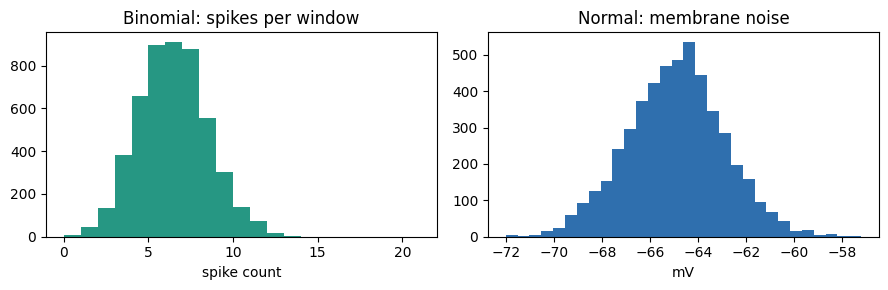

In [19]:
n = 20
spikes = rng.binomial(n, p, size=5000)              # spikes per 20-bin window
noise = rng.normal(loc=-65, scale=2.0, size=5000)   # mV around resting potential

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(spikes, bins=range(0, n + 2), color=C_NEURO, alpha=0.9)
ax[0].set(title="Binomial: spikes per window", xlabel="spike count")
ax[1].hist(noise, bins=30, color=C_TRAIN, alpha=0.9)
ax[1].set(title="Normal: membrane noise", xlabel="mV")
plt.tight_layout()
plt.show()

The binomial has two knobs: `n`, how many bins you watch, and `p`, how likely a spike is in each one. Drag them in the demo below and watch where the pile of counts sits and how wide it gets. The orange line marks `n · p`, which is where you would expect the average to land.

In [20]:
#@title 🔧 Binomial slider demo (run me, no need to read)
def binomial_demo(n=20, p=0.3):
    draws = rng.binomial(n, p, size=5000)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(draws, bins=range(0, n + 2), color=C_NEURO, alpha=0.9, edgecolor="white")
    ax.axvline(n * p, color=C_TEST, lw=2, label=f"expected n·p = {n * p:.1f}")
    ax.set(title="Binomial: spikes per window", xlabel="spike count", ylabel="count")
    ax.legend()
    plt.show()


interact(binomial_demo,
         n=IntSlider(min=5, max=50, step=5, value=20),
         p=FloatSlider(min=0.05, max=0.95, step=0.05, value=0.3))

interactive(children=(IntSlider(value=20, description='n', max=50, min=5, step=5), FloatSlider(value=0.3, desc…

<function __main__.binomial_demo(n=20, p=0.3)>

## 6. Tables with pandas

A NumPy array is all one type and has no column names, which gets painful the moment your data has a mix of text labels and numbers, as the scatter plot in section 3 did. pandas adds the **DataFrame**: a table with named columns, where each column can hold a different type. Think of a spreadsheet you can slice, group and summarise in code instead of by hand. Every dataset we load this term arrives as one.

### Building a DataFrame

One way in is a dictionary of columns, where each key becomes a column name. Every column has to be the same length, since they line up row by row. This is the same eight trials you plotted earlier, now with the condition as a proper label rather than a True/False mask.

In [21]:
df = pd.DataFrame({
    "trial": np.arange(1, 9),
    "condition": ["rest", "rest", "rest", "rest", "task", "task", "task", "task"],
    "spike_count": spike_count,
    "reaction_ms": reaction_ms,
})

print(df)

   trial condition  spike_count  reaction_ms
0      1      rest           11        560.0
1      2      rest            9        580.0
2      3      rest           13        510.0
3      4      rest           10        545.0
4      5      task           21        410.0
5      6      task           25        395.0
6      7      task           19        430.0
7      8      task           23        405.0


### Summarising and filtering

`.describe()` gives you the count, mean, standard deviation and quartiles of every numeric column at once, and it is usually the first thing worth running on a dataset you have not seen before. Square brackets pick out a column by name, and handing them a condition instead gives back only the rows where it holds. That is the same boolean masking idea from section 2, now applied to a whole table.

In [22]:
print(df.describe())

         trial  spike_count  reaction_ms
count  8.00000     8.000000     8.000000
mean   4.50000    16.375000   479.375000
std    2.44949     6.345696    77.249018
min    1.00000     9.000000   395.000000
25%    2.75000    10.750000   408.750000
50%    4.50000    16.000000   470.000000
75%    6.25000    21.500000   548.750000
max    8.00000    25.000000   580.000000


In [23]:
print(df[df["condition"] == "task"])

   trial condition  spike_count  reaction_ms
4      5      task           21        410.0
5      6      task           25        395.0
6      7      task           19        430.0
7      8      task           23        405.0


### Task 5 — group and summarise

`groupby` splits a table into groups that share a value, applies a summary to each group, and stacks the answers back together. It is the single most useful thing pandas does, and you will use it in nearly every notebook from here.

Using `df`, compute `mean_spikes`: the mean `spike_count` for each condition. You want `df.groupby(...)[...].mean()`, and the result should have one row for `"rest"` and one for `"task"`.

In [24]:
mean_spikes = df.groupby("condition")["spike_count"].mean()

In [25]:
# ✅ CHECK 5
check("mean_spikes has one row per condition",
      lambda: len(mean_spikes) == 2,
      hint="group by 'condition', then take the mean of 'spike_count'")
check("task fires more than rest (as expected)",
      lambda: mean_spikes["task"] > mean_spikes["rest"],
      hint="df.groupby('condition')['spike_count'].mean()")

✅  mean_spikes has one row per condition
✅  task fires more than rest (as expected)


<details><summary>💡 Reveal solution (Task 5)</summary>

```python
mean_spikes = df.groupby("condition")["spike_count"].mean()
```
</details>

## 7. Summarising a batch of numbers

There are two things we nearly always want to know about a batch of numbers: roughly where it sits, and how spread out it is. For the centre we have the **mean**, the arithmetic average, and the **median**, the middle value once you sort them. For the spread we have the **standard deviation**, a typical distance from the mean, and the **interquartile range** or IQR.

The IQR needs one more definition. Sort your data and the **quartiles** are the values a quarter and three quarters of the way through, written Q1 and Q3. The IQR is simply Q3 − Q1, the width of the middle half of the data. Those are the numbers `.describe()` was printing at you a moment ago.

The distinction that matters for messy neuroscience data is that **the median and the IQR resist outliers**, because both depend only on where values sit in the sorted order, while the mean and the standard deviation get dragged around by any extreme value. Two slow trials are enough to show it:

In [26]:
rt = rng.normal(350, 40, 200)            # reaction times (ms)
rt = np.append(rt, [900, 950])           # two slow outliers

print(f"mean   = {rt.mean():.1f} ms     median = {np.median(rt):.1f} ms")
print(f"SD     = {rt.std(ddof=1):.1f} ms     IQR    = "
      f"{np.percentile(rt, 75) - np.percentile(rt, 25):.1f} ms")

mean   = 355.9 ms     median = 352.1 ms
SD     = 71.2 ms     IQR    = 55.8 ms


The `ddof=1` there asks for the *sample* standard deviation, which divides by `n - 1` rather than `n`. It is the version you almost always want, because you are nearly always treating your data as a sample drawn from some larger population rather than as the whole population itself.

### A boxplot is a picture of these numbers

A boxplot draws exactly the summary we just computed: the median as the line, a box spanning Q1 to Q3 so its height *is* the IQR, and whiskers reaching towards the extremes. It is the fastest way to compare the spread of two conditions side by side.

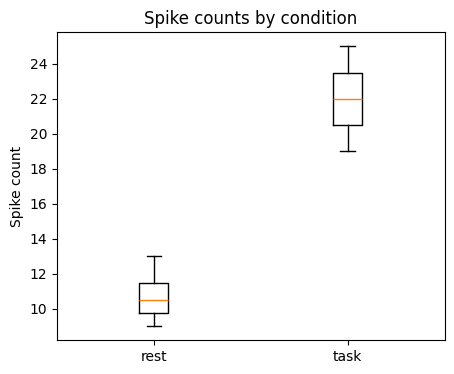

In [27]:
rest_counts = df.loc[df["condition"] == "rest", "spike_count"]
task_counts = df.loc[df["condition"] == "task", "spike_count"]

fig, ax = plt.subplots(figsize=(5, 4))

boxplot(ax, [rest_counts, task_counts], ["rest", "task"])

ax.set_ylabel("Spike count")
ax.set_title("Spike counts by condition")
plt.show()

The demo below makes the robustness point interactive. Drag the single outlier to the right and watch the mean chase after it while the median barely moves. Run it headless and it draws the starting frame instead.

In [28]:
#@title 🔧 Outlier slider demo (run me, no need to read)
baseline_rt = rng.normal(350, 40, 200)   # a clean batch of reaction times (ms)


def outlier_demo(outlier=350.0):
    data = np.append(baseline_rt, outlier)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(data, bins=30, color=C_NEURO, edgecolor="white", alpha=0.8)
    ax.axvline(np.mean(data), color=C_TEST, lw=2,
               label=f"mean = {np.mean(data):.0f}")
    ax.axvline(np.median(data), color=C_TRAIN, lw=2, ls="--",
               label=f"median = {np.median(data):.0f}")
    ax.set_xlabel("Reaction time (ms)")
    ax.set_ylabel("Count")
    ax.set_title("One outlier moves the mean far more than the median")
    ax.legend()
    plt.show()


interact(outlier_demo, outlier=FloatSlider(min=350, max=1500, step=50, value=350))

interactive(children=(FloatSlider(value=350.0, description='outlier', max=1500.0, min=350.0, step=50.0), Outpu…

<function __main__.outlier_demo(outlier=350.0)>

### Task 6 — median and IQR

From `rt`, the batch with the two slow outliers in it, compute `med`, the median, and `iqr`, the interquartile range. You want `np.median(...)` for the first, and for the second `np.percentile(rt, 75)` minus `np.percentile(rt, 25)`.

In [29]:
med = np.median(rt)
iqr = np.percentile(rt, 75) - np.percentile(rt, 25)

In [30]:
# ✅ CHECK 6
check("median looks right",
      lambda: np.isclose(med, np.median(rt)),
      hint="med = np.median(rt)")
check("IQR looks right",
      lambda: np.isclose(iqr, np.percentile(rt, 75) - np.percentile(rt, 25)),
      hint="iqr = np.percentile(rt, 75) - np.percentile(rt, 25)")

✅  median looks right
✅  IQR looks right


<details><summary>💡 Reveal solution (Task 6)</summary>

```python
med = np.median(rt)
iqr = np.percentile(rt, 75) - np.percentile(rt, 25)
```
</details>

### Task 7 — standardising with z-scores

A **z-score** says how many standard deviations a value sits from the mean of its batch. Standardising this way lets you compare measurements recorded on completely different scales, a firing rate against a reaction time say, and it is something you will do all term.

Complete `zscore_list` so that it subtracts the mean and then divides by the standard deviation, using the sample SD by default for the reason given above.

In [31]:
def zscore_list(values, ddof=1):
    """Return z-scores of a list of numbers (sample SD by default)."""
    arr = np.asarray(values, dtype=float)
    return (arr - arr.mean()) / arr.std(ddof=ddof)

In [32]:
# ✅ CHECK 7
zs = zscore_list([12, 15, 9, 22, 14])

check("z-scores have mean ≈ 0", lambda: abs(np.mean(zs)) < 1e-9,
      hint="subtract arr.mean() before dividing")
check("z-scores have SD ≈ 1", lambda: np.isclose(np.std(zs, ddof=1), 1.0),
      hint="divide by arr.std(ddof=ddof)")

# Once this passes, call it again with ddof=0 and see how much the SD moves.

✅  z-scores have mean ≈ 0
✅  z-scores have SD ≈ 1


<details><summary>💡 Reveal solution (Task 7)</summary>

```python
def zscore_list(values, ddof=1):
    arr = np.asarray(values, dtype=float)
    return (arr - arr.mean()) / arr.std(ddof=ddof)
```
</details>

## 8. Samples, and why their means behave

We almost never measure a whole **population**. We measure a **sample** drawn from it: forty trials, twenty neurons, whatever the experiment allowed. One awkward consequence follows immediately, and most of statistics is a response to it. Any number you compute from a sample, its mean included, would have come out somewhat differently had you happened to sample differently.

So the mean of a single sample is itself a slightly noisy quantity. The remarkable part is what happens when you imagine repeating the experiment many times over and collecting all of those means together. They pile up into a bell, and they do it even when the population you drew them from looks nothing like a bell. That result is the **Central Limit Theorem**, and it is a large part of why the normal distribution turns up everywhere.

You are not expected to prove this, or to be able to state the conditions under which it holds. Watch it happen instead. The animation draws sample after sample from a lopsided population and drops each sample's mean into a histogram until the bell appears.

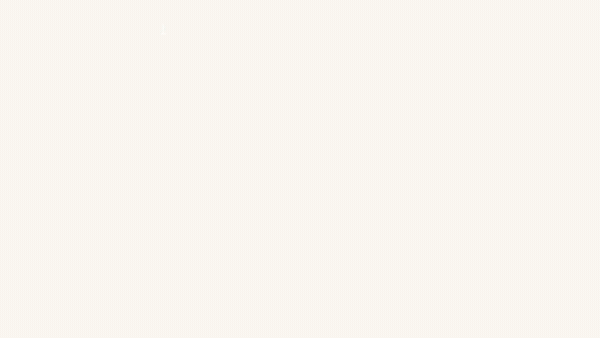

Here is the same thing in code. `rng.exponential` gives us a deliberately lopsided population, with many small values and a long tail of large ones, which is about as un-bell-like as it gets. The left panel is that population; the right is what happens to the means of 2000 samples taken from it.

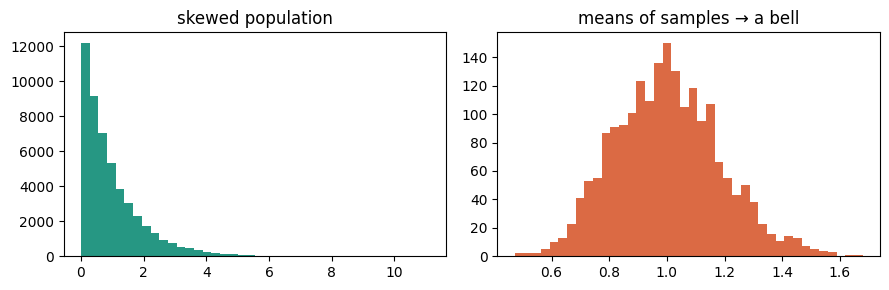

population mean = 1.000;  mean of sample-means = 1.002


In [33]:
pop = rng.exponential(scale=1.0, size=50_000)                       # a skewed "population"
sample_means = np.array([rng.choice(pop, size=30).mean() for _ in range(2000)])

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(pop, bins=40, color=C_NEURO, alpha=0.9)
ax[0].set(title="skewed population")
ax[1].hist(sample_means, bins=40, color=C_TEST, alpha=0.9)
ax[1].set(title="means of samples → a bell")
plt.tight_layout()
plt.show()

print(f"population mean = {pop.mean():.3f};  mean of sample-means = {sample_means.mean():.3f}")

Now drag the sample size in the demo below and watch one thing in particular: as the samples get bigger, the bell gets **narrower**. That is the whole reason bigger experiments give more trustworthy answers, and L2 makes the relationship precise.

In [34]:
#@title 🔧 Central Limit Theorem slider demo (run me, no need to read)
def clt_demo(sample_size=30):
    means = np.array([rng.choice(pop, size=sample_size).mean() for _ in range(2000)])
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(means, bins=40, color=C_TEST, alpha=0.9, edgecolor="white")
    ax.axvline(pop.mean(), color=C_TRAIN, lw=2, label=f"population mean = {pop.mean():.2f}")
    ax.set(title=f"Means of {sample_size}-sample draws (SD = {means.std():.3f})",
           xlabel="sample mean", ylabel="count")
    ax.set_xlim(0.4, 1.7)
    ax.legend()
    plt.show()


interact(clt_demo, sample_size=IntSlider(min=2, max=200, step=2, value=30))

interactive(children=(IntSlider(value=30, description='sample_size', max=200, min=2, step=2), Output()), _dom_…

<function __main__.clt_demo(sample_size=30)>

### Task 8 — bigger samples, tighter bell

Take 2000 samples of size 100 from `pop`, store each sample's mean in `big_means`, and put the standard deviation of those means into `sd_100`. Because the samples are bigger, that spread should come out well below what you saw at size 30. Copy the list comprehension from the cell above and change the size.

In [35]:
big_means = np.array([rng.choice(pop, size=100).mean() for _ in range(2000)])
sd_100 = np.std(big_means)

In [36]:
# ✅ CHECK 8
check("big_means holds 2000 sample means",
      lambda: len(big_means) == 2000,
      hint="big_means = np.array([rng.choice(pop, size=100).mean() for _ in range(2000)])")
check("SD of the mean shrank with bigger samples (sd_100 < 0.14)",
      lambda: 0 < sd_100 < 0.14,
      hint="sd_100 = np.std(big_means); larger samples give a smaller SD of the mean")

✅  big_means holds 2000 sample means
✅  SD of the mean shrank with bigger samples (sd_100 < 0.14)


<details><summary>💡 Reveal solution (Task 8)</summary>

```python
big_means = np.array([rng.choice(pop, size=100).mean() for _ in range(2000)])
sd_100 = np.std(big_means)
```
</details>

One question we have deliberately left alone: when two conditions differ, how do you tell a real effect from luck? Answering it needs a **hypothesis test**, which L2 builds from scratch. Everything in this section is the groundwork for it, so you are better placed than you might think.

## 9. Mini-project

Everything above now gets used on one question. A colleague hands you a CSV of reaction times from two conditions and asks whether the task really slowed people down. The shape of the answer is the shape of every analysis this term:

> **load → clean → summarise → visualise → save**

Each step gets its own cell. Most are written for you; the loading and the cleaning are yours.

### Step 0 — make the data

Normally someone hands you the file. Here we have to invent it first, so we draw sixty trials per condition from a normal distribution around a different mean for each, and then deliberately break two values. Injecting known bad data is a good habit, because it is the only way to be sure your cleaning code catches anything.

We write it to the system temp directory, which is scratch space your operating system clears out on its own, so the notebook leaves nothing behind. `index=False` stops pandas writing its row numbers out as an extra unnamed column.

In [37]:
n_per_condition = 60
rest_rt = rng.normal(loc=540, scale=60, size=n_per_condition)
task_rt = rng.normal(loc=420, scale=55, size=n_per_condition)

sim = pd.DataFrame({
    "condition": ["rest"] * n_per_condition + ["task"] * n_per_condition,
    "reaction_ms": np.concatenate([rest_rt, task_rt]).round(1),
})

sim.loc[0, "reaction_ms"] = -5.0      # impossible: negative time
sim.loc[1, "reaction_ms"] = 9999.0    # implausible: a recording glitch

csv_path = os.path.join(tempfile.gettempdir(), "nb0_reaction_times.csv")
sim.to_csv(csv_path, index=False)

print(f"Wrote {len(sim)} rows to:\n  {csv_path}")

Wrote 120 rows to:
  /tmp/nb0_reaction_times.csv


### Task 9 — step 1, load

Read the CSV at `csv_path` into a DataFrame called `project`, using `pd.read_csv(...)`.

In [38]:
project = pd.read_csv(csv_path)

In [39]:
# ✅ CHECK 9
check("project has all the rows",
      lambda: len(project) == 2 * n_per_condition,
      hint="project = pd.read_csv(csv_path)")
check("it has the expected columns",
      lambda: list(project.columns) == ["condition", "reaction_ms"],
      hint="read the file we just wrote at csv_path")

✅  project has all the rows
✅  it has the expected columns


<details><summary>💡 Reveal solution (Task 9)</summary>

```python
project = pd.read_csv(csv_path)
```
</details>

In [40]:
#@title 🔧 Safety net (run me): make sure the project data is loaded
# If Task 9 is still blank, load the file anyway so the rest of section 9 runs
# and you can read the steps in order. CHECK 10 above still reports honestly.
if not isinstance(project, pd.DataFrame):
    project = pd.read_csv(csv_path)
    print("Task 10 is still blank, so I've loaded the data for you. The rest of the section will run.")
else:
    print(f"Using your loaded data: {len(project)} rows.")

Using your loaded data: 120 rows.


### Task 10 — step 2, clean

Keep only plausible reaction times, meaning strictly greater than 0 and strictly less than 3000 ms, and assign the filtered DataFrame back to `project`. Use a boolean mask, exactly as in section 6. Note that the two conditions need combining with `&` rather than the word `and`, which is one of pandas' small but persistent annoyances.

In [41]:
before = len(project)

project = project[(project["reaction_ms"] > 0) & (project["reaction_ms"] < 3000)]

removed = before - len(project)
print(f"Removed {removed} implausible rows. {len(project)} remain.")

Removed 2 implausible rows. 118 remain.


In [42]:
# ✅ CHECK 10
check("exactly the two injected bad rows were removed", lambda: removed == 2,
      hint="keep rows where (reaction_ms > 0) & (reaction_ms < 3000)")

✅  exactly the two injected bad rows were removed


<details><summary>💡 Reveal solution (Task 10)</summary>

```python
project = project[(project["reaction_ms"] > 0) & (project["reaction_ms"] < 3000)].copy()
```
</details>

### Step 3 — summarise

`.agg()` lets you ask for several summaries in one call and name each resulting column. Note that we report the median and the IQR alongside the mean and the SD, for the reason section 7 gave.

In [43]:
summary = project.groupby("condition")["reaction_ms"].agg(
    n="count", mean="mean", median="median", sd="std"
).round(1)

print(summary)

            n   mean  median    sd
condition                         
rest       58  538.2   537.8  51.6
task       60  423.0   425.9  48.6


### Step 4 — visualise

Two histograms drawn onto the same axes. The `alpha=0.6` makes each one partly transparent, so that you can still see where the two conditions overlap rather than the later one simply hiding the earlier.

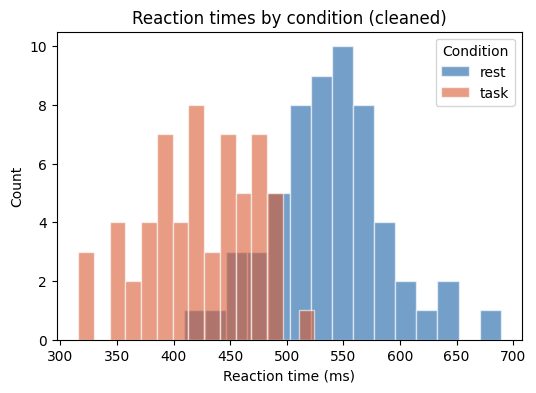

In [44]:
fig, ax = plt.subplots(figsize=(6, 4))

for cond, colour in [("rest", C_TRAIN), ("task", C_TEST)]:
    sub = project.loc[project["condition"] == cond, "reaction_ms"]
    ax.hist(sub, bins=15, alpha=0.6, label=cond, color=colour, edgecolor="white")

ax.set_xlabel("Reaction time (ms)")
ax.set_ylabel("Count")
ax.set_title("Reaction times by condition (cleaned)")
ax.legend(title="Condition")
plt.show()

### Step 5 — save

Write out both the figure and the cleaned data, so that the analysis leaves behind something a colleague could pick up and check. Saving the cleaned data alongside the figure is what makes a result reproducible rather than merely claimed.

In [45]:
fig_path = os.path.join(tempfile.gettempdir(), "nb0_reaction_times.png")
clean_path = os.path.join(tempfile.gettempdir(), "nb0_reaction_times_clean.csv")

fig.savefig(fig_path, dpi=120, bbox_inches="tight")
project.to_csv(clean_path, index=False)

print("Saved figure to", fig_path)
print("Saved clean data to", clean_path)

Saved figure to /tmp/nb0_reaction_times.png
Saved clean data to /tmp/nb0_reaction_times_clean.csv


That is the whole loop, and it is the one every later notebook repeats. What changes is the middle: instead of comparing two means you will fit a regression, then a classifier, then a neural network. The loading, cleaning and saving around the outside stay much as they are here.

## Before you move on

Run the cell below for your tally.

In [46]:
score()


21/21 checks passing.
All green. You're warmed up for MAM5017S, see you in class.


*See you on Wednesday 29 July.*